# Per-bit intensity profile across FOVs, and comparison to MERlin's own optimized scale factors

Follow-up to the WAI investigation (`01_test_weighted_average_intensity.ipynb`):
instead of averaging the 16 barcode bits' per-FOV mean intensity into one WAI
scalar, keep each bit's own per-FOV mean intensity separate. This checks two
things:

1. Does every bit's per-FOV intensity profile have roughly the same *shape*
   across FOVs (as WAI's single averaged profile suggested)? If so, an affine
   rescaling of each bit's profile -- `y_scaled(bitX, i) =
   Factor_bitX * (y_original(bitX, i) - min(y_original(bitX)))` -- should
   bring all 16 profiles into close overlap.
2. How does the per-bit `Factor_bitX` needed to do that compare to the
   per-bit scale factor MERlin's own `Optimize` task converges to (used
   directly by `Decode` to normalize each bit before barcode matching)? Both
   are, in different ways, "how much does this bit's raw intensity need to
   be rescaled to be comparable to the others" -- if the two agree, a
   perfectly-scaled per-bit profile computed from raw images *before*
   decoding could stand in for (or sanity-check) MERlin's own optimization.

**Dataset**: `BC555_sample_05/epi`, same z-plane resolution and bit lookup
as `01_test_weighted_average_intensity.ipynb` (reused via
`MERci.analysis.fov.resolve_barcode_bit_lookup`, factored out for this
purpose -- see that function's docstring for the round_bit_color_map.csv
cross-reference it replaces).

**Images produced**:
- per-bit mean intensity vs. FOV index, 16 lines (one per bit)
- the same 16 profiles after the affine rescaling, to check how well they overlay
- `Factor_bitX` (inverted, `1/Factor_bitX`, so both axes increase with bit
  brightness) vs. MERlin's own converged per-bit scale factor
- the raw/MERlin-processed comparison above, repeated for the MERlin-processed
  images, plus a third panel comparing MERlin's own `Optimize10` scale
  factors directly to `Optimize09`'s
- Pearson r of every earlier `Optimize01`..`Optimize09` iteration's scale
  factors against `Optimize10`'s, vs. iteration number

Follows `NOTEBOOK_GUIDELINES.md`: calculation cached under
`analysis/cache/test_intensity_vs_bit/`, skip already-done FOVs on rerun,
`ProgressReporter` progress; display cells separate, every figure saved to
`analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.analysis.fov           import resolve_barcode_bit_lookup
from MERci.progress_display       import ProgressReporter
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_intensity_vs_bit"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# This is a test/investigation notebook (NOTEBOOK_GUIDELINES.md's "validation
# notebooks for a new feature" case under notebooks/tests/) -- it analyzes an
# EXTERNAL dataset, not the experiment this MERci clone is deployed into, so
# SAMPLE_DIR is set explicitly rather than auto-detected from parent dirs.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
IMAGE_SUFFIX = ".zarr"

N_BARCODE_BITS = 16

Z_PLANE = None   # None = auto-pick the middle z of the bits round's frame table (section 4);
                 # same auto-pick as 01_test_weighted_average_intensity.ipynb for a like-for-like comparison.

FORCE_RECOMPUTE = False

# MERlin's own converged per-bit scale factors (section 8): Decode's real
# `optimize_task` per merlin_analysis_BC555_sample_05.yaml -- the last
# iteration in the chained OptimizeIteration sequence (Optimize01 -> ... ->
# Optimize10, each depending on the previous one's result).
MERLIN_OPTIMIZE_DIR = SAMPLE_DIR / "merlin" / "output" / "Optimize10"

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 9

print(f"SAMPLE_DIR          : {SAMPLE_DIR}")
print(f"MERLIN_OPTIMIZE_DIR : {MERLIN_OPTIMIZE_DIR}")

SAMPLE_DIR          : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
MERLIN_OPTIMIZE_DIR : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/merlin/output/Optimize10


## 3 — Resolve dataset geometry

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

# NOTEBOOK_GUIDELINES.md #2: cache under analysis/cache/<notebook_name>/.
CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / "intensity_per_fov_per_bit.csv"

# NOTEBOOK_GUIDELINES.md #6: figures under figures/MERci/tests/optimization_fov_selection/{NOTEBOOK_NAME}/.
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="optimization_fov_selection")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

round_info = pd.read_csv(config.round_info_csv)

print(f"Sample name: {sample_name}")
print(f"FOVs       : {meta.n_fovs}")
print(f"Cache      : {CACHE_PATH}")
print(f"Figures    : {FIGURES_DIR}")

Sample name: BC555_sample_05
FOVs       : 476
Cache      : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv
Figures    : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/figures/MERci/tests/optimization_fov_selection/test_intensity_vs_bit


## 4 — Resolve the per-bit lookup

Reuses `MERci.analysis.fov.resolve_barcode_bit_lookup` (relocated from
`01_test_weighted_average_intensity.ipynb`'s own section 4 so this second
notebook doesn't duplicate the round_bit_color_map.csv/round_info.csv
cross-reference).

In [4]:
bit_lookup, bits_series_by_round, Z_PLANE = resolve_barcode_bit_lookup(
    config, meta, round_info, n_barcode_bits=N_BARCODE_BITS, z_plane=Z_PLANE,
)

print(f"Z_PLANE (chosen): {Z_PLANE}")
for bit, (rid, fidx) in sorted(bit_lookup.items()):
    print(f"  bit {bit:2d}: round {rid}, frame {fidx}")

Z_PLANE (chosen): 13
  bit  1: round 1, frame 37
  bit  2: round 1, frame 38
  bit  3: round 2, frame 37
  bit  4: round 2, frame 38
  bit  5: round 3, frame 37
  bit  6: round 3, frame 38
  bit  7: round 4, frame 37
  bit  8: round 4, frame 38
  bit  9: round 5, frame 37
  bit 10: round 5, frame 38
  bit 11: round 6, frame 37
  bit 12: round 6, frame 38
  bit 13: round 7, frame 37
  bit 14: round 7, frame 38
  bit 15: round 8, frame 37
  bit 16: round 8, frame 38


## 5 — Calculation: per-FOV, per-bit mean intensity

**Calculation cell** (`NOTEBOOK_GUIDELINES.md` #1/#2/#3/#4): for every FOV
and every barcode bit, reads that bit's frame at `Z_PLANE` (true partial
read via `read_image_frames`) and records its mean pixel intensity -- long
format (`fov_id`, `bit`, `mean_intensity`), one row per (FOV, bit). Cached
to `analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv`; a
FOV already fully cached (all `N_BARCODE_BITS` bits present) is skipped on
rerun unless `FORCE_RECOMPUTE`.

In [5]:
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    cache_df = pd.read_csv(CACHE_PATH)
else:
    cache_df = pd.DataFrame(columns=["fov_id", "bit", "mean_intensity"])

done_fovs = {fov_id for fov_id, n in cache_df.groupby("fov_id").size().items() if n == N_BARCODE_BITS}
all_fov_ids  = sorted(meta.fovs)
todo_fov_ids = [f for f in all_fov_ids if f not in done_fovs]

print(f"{len(done_fovs)} / {len(all_fov_ids)} FOV(s) already cached; computing {len(todo_fov_ids)} more.")

new_rows = []
reporter = ProgressReporter(total=len(todo_fov_ids), label="Computing per-FOV, per-bit intensity")
for fov_id in todo_fov_ids:
    for bit, (round_id, frame_idx) in bit_lookup.items():
        series = bits_series_by_round[round_id]
        path   = series.resolve_path(fov_id, config.image_suffix)
        frame  = read_image_frames(path, [frame_idx])[0]
        new_rows.append({"fov_id": fov_id, "bit": bit, "mean_intensity": float(frame.mean())})
    reporter.update()
reporter.done()

if new_rows:
    cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
    cache_df = cache_df.drop_duplicates(subset=["fov_id", "bit"]).sort_values(["fov_id", "bit"]).reset_index(drop=True)
    cache_df.to_csv(CACHE_PATH, index=False)

wide = cache_df.pivot(index="fov_id", columns="bit", values="mean_intensity").sort_index()
print(f"Intensity computed for {wide.shape[0]} FOV(s) x {wide.shape[1]} bit(s). Cache: {CACHE_PATH}")

476 / 476 FOV(s) already cached; computing 0 more.
Computing per-FOV, per-bit intensity: 0 done  elapsed 0s          


Intensity computed for 476 FOV(s) x 16 bit(s). Cache: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv


## 6 — Per-bit mean intensity vs. FOV index

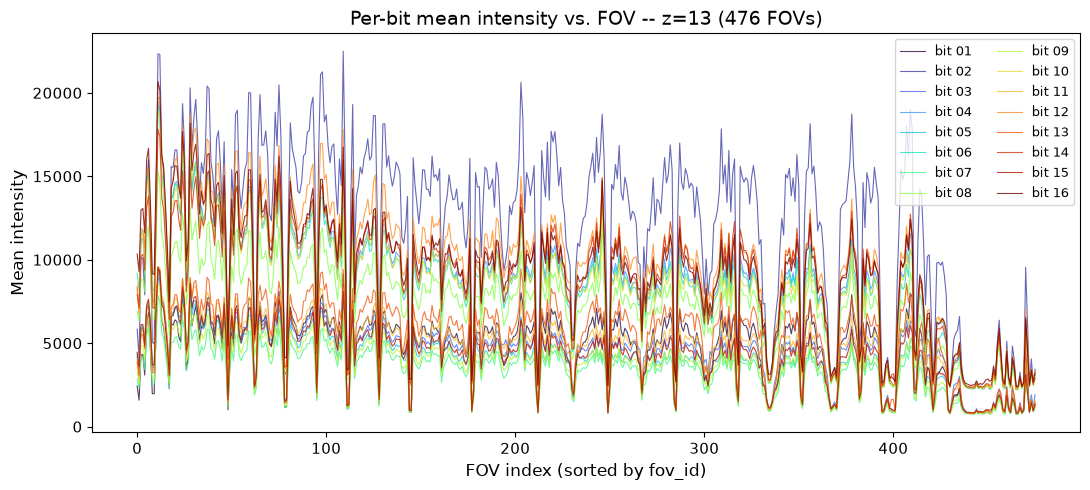

In [6]:
fov_index = np.arange(len(wide))
bits = sorted(wide.columns)
cmap = plt.cm.turbo
color_of = {b: cmap(i / max(len(bits) - 1, 1)) for i, b in enumerate(bits)}

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, wide[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Mean intensity", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit mean intensity vs. FOV -- z={Z_PLANE} ({len(fov_index)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_per_bit.png", dpi=150)
plt.show()

## 7 — Affine overlay: per-bit scaling factors

For each bit, subtract that bit's own minimum across FOVs
(`y - min(y)`), then find the single multiplicative `Factor_bitX` that best
overlays the min-subtracted profile onto a **consensus shape**: the average,
across all 16 bits, of each bit's own min-subtracted profile independently
rescaled to `[0, 1]` (`(y - min) / (max - min)`). `Factor_bitX` is then the
least-squares scale of the min-subtracted profile onto that consensus (no
intercept -- the subtraction already anchors it at 0):

`Factor_bitX = <(y_bitX - min_bitX), consensus> / <(y_bitX - min_bitX), (y_bitX - min_bitX)>`

which is exactly `y_scaled(bitX, i) = Factor_bitX * (y_original(bitX, i) -
min(y_original(bitX)))` as specified, with the consensus (rather than one
arbitrarily chosen bit) as the common target every profile is fit to.

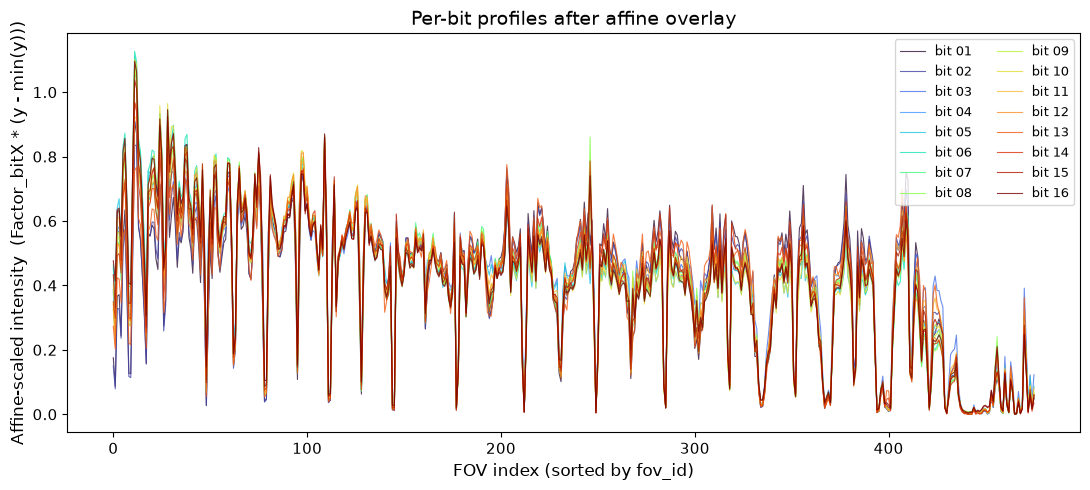

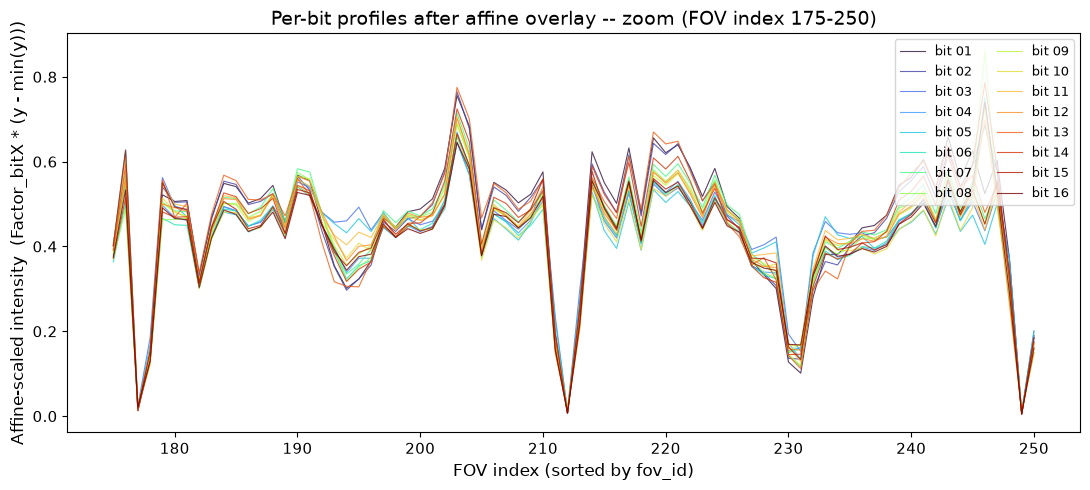

Factor_bitX:
1     0.000104
2     0.000042
3     0.000112
4     0.000064
5     0.000127
6     0.000067
7     0.000155
8     0.000083
9     0.000138
10    0.000066
11    0.000105
12    0.000055
13    0.000090
14    0.000063
15    0.000119
16    0.000060


In [7]:
min_per_bit = wide.min(axis=0)
range_per_bit = wide.max(axis=0) - min_per_bit
centered = wide.subtract(min_per_bit, axis=1)                       # y - min(y), per bit
normalized_01 = centered.divide(range_per_bit, axis=1)               # (y - min) / (max - min), per bit
consensus = normalized_01.mean(axis=1).values                        # average shape across all 16 bits

factor_per_bit = {}
for b in bits:
    y = centered[b].values
    factor_per_bit[b] = float(np.dot(y, consensus) / np.dot(y, y))
factor_series = pd.Series(factor_per_bit).sort_index()

scaled = centered.multiply(factor_series, axis=1)   # y_scaled(bitX, i) = Factor_bitX * (y - min(y))

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, scaled[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity  (Factor_bitX * (y - min(y)))", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Per-bit profiles after affine overlay", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay.png", dpi=150)
plt.show()

# Zoom: FOV index 175-250, restricted to that range (not just an xlim on the
# full-range plot above) so the y-axis autoscales to the zoomed-in data too.
zoom_mask = (fov_index >= 175) & (fov_index <= 250)
fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index[zoom_mask], scaled[b].values[zoom_mask], "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity  (Factor_bitX * (y - min(y)))", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Per-bit profiles after affine overlay -- zoom (FOV index 175-250)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay_zoom_175_250.png", dpi=150)
plt.show()

print("Factor_bitX:")
print(factor_series.to_string())

## 8 — Compare to MERlin's own optimized scale factors

MERlin's `Decode` task (`merlin_analysis_BC555_sample_05.yaml`) uses
`Optimize10` -- the last in the chained `Optimize01 -> ... -> Optimize10`
`OptimizeIteration` sequence, each depending on the previous one's result.
Its `scale_factors.npy` (16 values, index *i* = bit *i+1*, confirmed against
`codebook_0_C3v1_codebook.csv`'s RS-column order via the data-organization
CSV's `bitNumber` column) is `nanmedian(refactor * previous_scale_factor)`
across that iteration's FOV fragments (`merlin/analysis/optimize.py`,
`OptimizeIteration.get_scale_factors`) -- the actual per-bit rescale MERlin
converged to before decoding.

`Factor_bitX` (section 7) and MERlin's scale factor move in *opposite*
directions with bit brightness: a bright bit has a large raw-intensity
range, so needs a *small* `Factor_bitX` to reach the ~[0,1] consensus scale,
while MERlin's scale factor for a bright bit is *larger* (it divides the
raw signal down to a common scale). `1/Factor_bitX` is plotted against
MERlin's scale factor so both axes increase with bit brightness, for a
directly interpretable comparison.

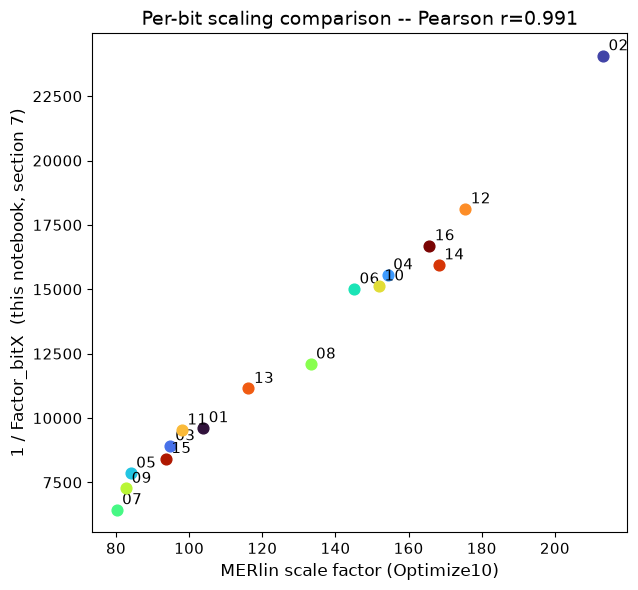

    Factor_bitX  1/Factor_bitX  merlin_scale_factor
1        0.0001      9622.9006             103.8476
2        0.0000     24068.6264             213.1545
3        0.0001      8917.6618              94.6972
4        0.0001     15561.3438             154.2823
5        0.0001      7857.8742              84.0162
6        0.0001     15011.8633             145.0782
7        0.0002      6437.2544              80.1644
8        0.0001     12094.6296             133.1816
9        0.0001      7266.7464              82.7678
10       0.0001     15128.5950             151.8815
11       0.0001      9534.5550              97.9998
12       0.0001     18123.9814             175.4937
13       0.0001     11147.8284             116.2236
14       0.0001     15947.7325             168.2566
15       0.0001      8425.8797              93.6160
16       0.0001     16688.6550             165.6545

Pearson r (1/Factor_bitX vs. MERlin scale factor): 0.9910


In [8]:
merlin_scale_factors = np.load(MERLIN_OPTIMIZE_DIR / "scale_factors.npy")
merlin_per_bit = pd.Series({i + 1: float(v) for i, v in enumerate(merlin_scale_factors)}).sort_index()

inv_factor_series = 1.0 / factor_series

comparison = pd.DataFrame({
    "Factor_bitX":            factor_series,
    "1/Factor_bitX":          inv_factor_series,
    "merlin_scale_factor":    merlin_per_bit,
})
r = np.corrcoef(comparison["1/Factor_bitX"], comparison["merlin_scale_factor"])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for b in bits:
    ax.scatter(comparison.loc[b, "merlin_scale_factor"], comparison.loc[b, "1/Factor_bitX"],
               color=color_of[b], s=60, zorder=3)
    ax.annotate(f"{b:02d}", (comparison.loc[b, "merlin_scale_factor"], comparison.loc[b, "1/Factor_bitX"]),
                fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("1 / Factor_bitX  (this notebook, section 7)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit scaling comparison -- Pearson r={r:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_comparison.png", dpi=150)
plt.show()

print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nPearson r (1/Factor_bitX vs. MERlin scale factor): {r:.4f}")

## 9 — Same calculation, starting from MERlin's processed images

Sections 1-8 all read the raw camera frame directly. But the per-bit scale
factor MERlin's `Optimize`/`Decode` tasks actually converge on (section 8)
is computed from images `DeconvolutionPreprocess` has already
warped+filtered -- not the raw frames. This section recomputes sections
5-8's calculation starting from that same preprocessed image instead, to
check whether that's why `Factor_bitX` and MERlin's own scale factor
disagree in magnitude/shape (section 8).

This dataset's own `DeconvolutionPreprocess` output
(`merlin/output/DeconvolutionPreprocess/images/preprocessed_images<fov>.tif`)
turns out to hold **no actual image data** -- confirmed directly: every one
of the 476 files is a 16-byte empty TIFF (`write_preprocessed_images`
defaults to `False` and isn't overridden in
`merlin_analysis_BC555_sample_05.yaml`; only the per-bit pixel *histogram*
was kept, not the per-pixel array). So the processed image is recomputed
here from the same raw frame `bit_lookup` (section 4) already reads,
calling MERlin's own real functions -- not a reimplementation -- to
replicate `merlin.analysis.preprocess.DeconvolutionPreprocess.
_preprocess_image` exactly as this dataset's own yaml configures it:

1. **Fiducial-correlation warp** -- the same per-(FOV, data channel)
   `skimage.transform.SimilarityTransform` MERlin's own
   `FiducialCorrelationWarp` computed and saved to
   `merlin/output/FiducialCorrelationWarp/transformations/offsets_<fov>.npy`
   (reused directly, not recomputed here -- the same file
   `03_test_bead_round_averaging.ipynb` reads for its own offset lookup).
   `dataChannel` per bit comes from `merlin/output/dataorganization.csv`'s
   own row order (`get_data_channel_for_bit` matches by `readoutName`, and
   `get_data_channels()` returns that row's index) -- confirmed **not**
   simply `bitNumber - 1`: non-combinatorial "sequential gene" channels are
   interleaved between the 16 barcode-bit rows.
2. **High-pass filter + deconvolution** -- calls
   `merlin.util.imagefilters.high_pass_filter` and
   `merlin.util.deconvolve.deconvolve_lucyrichardson` directly (the exact
   functions `DeconvolutionPreprocess._preprocess_image` calls), with
   `highpass_sigma`/`decon_sigma`/`decon_filter_size`/`decon_iterations`
   read from this dataset's own `merlin_analysis_BC555_sample_05.yaml`, not
   assumed. **Requires a kernel where `merlin` (and its own `cv2`
   dependency) are importable** -- `merci_env` doesn't have `cv2`; run this
   notebook under the environment MERlin itself runs in instead.

In [9]:
import yaml
from skimage import transform
from merlin.util import imagefilters, deconvolve

# ── MERlin's own DeconvolutionPreprocess config for this dataset, read
# straight from the yaml MERlin actually ran with (not assumed) ───────────
MERLIN_YAML_PATH = SAMPLE_DIR / "merlin" / "analysis" / f"merlin_analysis_{sample_name}.yaml"
_merlin_tasks = {t["task"]: t.get("parameters", {}) or {}
                 for t in yaml.safe_load(MERLIN_YAML_PATH.read_text())["analysis_tasks"]}
_decon_params = _merlin_tasks["DeconvolutionPreprocess"]

HIGHPASS_SIGMA    = _decon_params.get("highpass_sigma", 3)
DECON_SIGMA       = _decon_params.get("decon_sigma", 2)
DECON_ITERATIONS  = _decon_params.get("decon_iterations", 20)
HIGHPASS_WINDOW   = int(2 * np.ceil(2 * HIGHPASS_SIGMA) + 1)          # DeconvolutionPreprocess._high_pass_filter's own formula
DECON_FILTER_SIZE = _decon_params.get(
    "decon_filter_size", int(2 * np.ceil(2 * DECON_SIGMA) + 1))       # DeconvolutionPreprocess.__init__'s own default

# dataChannel per bit -- from MERlin's own dataorganization.csv row order,
# matched by readoutName (see markdown above); NOT simply bitNumber - 1.
MERLIN_DATAORG_PATH = SAMPLE_DIR / "merlin" / "output" / "dataorganization.csv"
dataorg = pd.read_csv(MERLIN_DATAORG_PATH)
data_channel_by_bit = {
    int(row.bitNumber): idx for idx, row in dataorg.iterrows()
    if str(row.channelName).startswith("bit") and row.bitNumber <= N_BARCODE_BITS
}

OFFSETS_DIR = SAMPLE_DIR / "merlin" / "output" / "FiducialCorrelationWarp" / "transformations"

print(f"HIGHPASS_SIGMA    : {HIGHPASS_SIGMA}")
print(f"HIGHPASS_WINDOW   : {HIGHPASS_WINDOW}")
print(f"DECON_SIGMA       : {DECON_SIGMA}")
print(f"DECON_FILTER_SIZE : {DECON_FILTER_SIZE}")
print(f"DECON_ITERATIONS  : {DECON_ITERATIONS}")
print(f"data_channel_by_bit: {data_channel_by_bit}")


def merlin_like_processed_frame(fov_id: int, bit: int) -> np.ndarray:
    """Recomputes MERlin's own DeconvolutionPreprocess output for one (fov, bit)
    at Z_PLANE, from the same raw frame bit_lookup (section 4) reads -- exactly
    replicating Warp.get_aligned_image + DeconvolutionPreprocess._preprocess_image
    (see section 9 markdown), calling MERlin's own real functions throughout."""
    round_id, frame_idx = bit_lookup[bit]
    series = bits_series_by_round[round_id]
    path = series.resolve_path(fov_id, config.image_suffix)
    raw = read_image_frames(path, [frame_idx])[0]

    offsets = np.load(OFFSETS_DIR / f"offsets_{fov_id}.npy")
    warp_transform = transform.SimilarityTransform(matrix=offsets[data_channel_by_bit[bit]])
    warped = transform.warp(raw, warp_transform, preserve_range=True).astype(raw.dtype)

    filtered = imagefilters.high_pass_filter(warped, HIGHPASS_WINDOW, HIGHPASS_SIGMA).astype(np.float32)
    processed = deconvolve.deconvolve_lucyrichardson(
        filtered, DECON_FILTER_SIZE, DECON_SIGMA, DECON_ITERATIONS).astype(np.uint16)
    return processed

HIGHPASS_SIGMA    : 3
HIGHPASS_WINDOW   : 13
DECON_SIGMA       : 2
DECON_FILTER_SIZE : 9
DECON_ITERATIONS  : 0
data_channel_by_bit: {1: 0, 2: 1, 3: 3, 4: 4, 5: 6, 6: 7, 7: 9, 8: 10, 9: 12, 10: 13, 11: 15, 12: 16, 13: 18, 14: 19, 15: 21, 16: 22}


## 10 — Calculation: per-FOV, per-bit mean intensity (MERlin-processed)

Same calculation as section 5, starting from `merlin_like_processed_frame`
instead of the raw frame. Cached separately to
`analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit_merlin_processed.csv`,
same skip-already-done-FOV behavior as section 5.

In [10]:
CACHE_PATH_PROCESSED = CACHE_DIR / "intensity_per_fov_per_bit_merlin_processed.csv"

if CACHE_PATH_PROCESSED.exists() and not FORCE_RECOMPUTE:
    cache_df_processed = pd.read_csv(CACHE_PATH_PROCESSED)
else:
    cache_df_processed = pd.DataFrame(columns=["fov_id", "bit", "mean_intensity"])

done_fovs_processed = {fov_id for fov_id, n in cache_df_processed.groupby("fov_id").size().items()
                        if n == N_BARCODE_BITS}
todo_fov_ids_processed = [f for f in all_fov_ids if f not in done_fovs_processed]

print(f"{len(done_fovs_processed)} / {len(all_fov_ids)} FOV(s) already cached; "
      f"computing {len(todo_fov_ids_processed)} more.")

new_rows = []
reporter = ProgressReporter(total=len(todo_fov_ids_processed),
                             label="Computing per-FOV, per-bit MERlin-processed intensity")
for fov_id in todo_fov_ids_processed:
    for bit in bits:
        frame = merlin_like_processed_frame(fov_id, bit)
        new_rows.append({"fov_id": fov_id, "bit": bit, "mean_intensity": float(frame.mean())})
    reporter.update()
reporter.done()

if new_rows:
    cache_df_processed = pd.concat([cache_df_processed, pd.DataFrame(new_rows)], ignore_index=True)
    cache_df_processed = (cache_df_processed.drop_duplicates(subset=["fov_id", "bit"])
                           .sort_values(["fov_id", "bit"]).reset_index(drop=True))
    cache_df_processed.to_csv(CACHE_PATH_PROCESSED, index=False)

wide_processed = cache_df_processed.pivot(index="fov_id", columns="bit", values="mean_intensity").sort_index()
print(f"MERlin-processed intensity computed for {wide_processed.shape[0]} FOV(s) x "
      f"{wide_processed.shape[1]} bit(s). Cache: {CACHE_PATH_PROCESSED}")

476 / 476 FOV(s) already cached; computing 0 more.
Computing per-FOV, per-bit MERlin-processed intensity: 0 done  elapsed 0s          


MERlin-processed intensity computed for 476 FOV(s) x 16 bit(s). Cache: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit_merlin_processed.csv


## 11 — Per-bit mean intensity vs. FOV index (MERlin-processed)

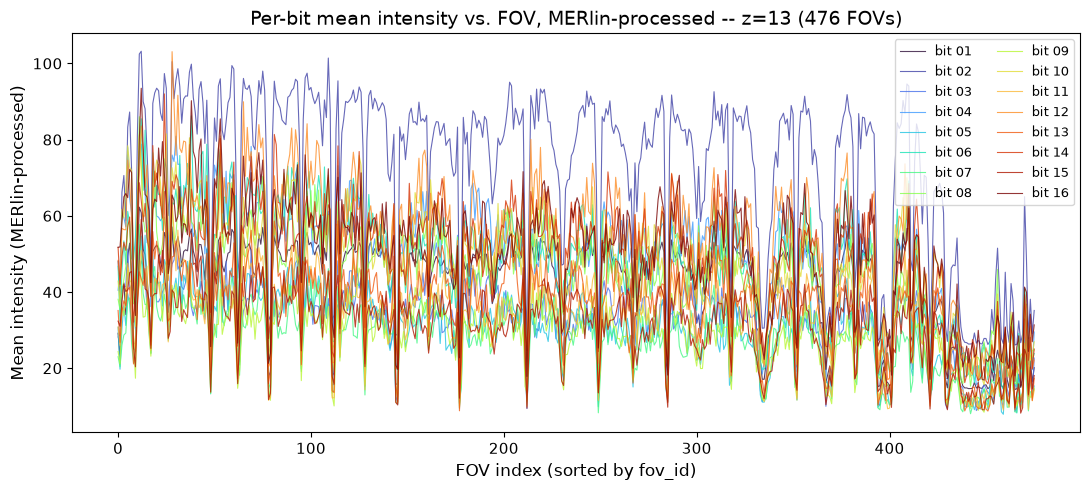

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, wide_processed[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Mean intensity (MERlin-processed)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit mean intensity vs. FOV, MERlin-processed -- z={Z_PLANE} ({len(fov_index)} FOVs)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_per_bit_merlin_processed.png", dpi=150)
plt.show()

## 12 — Affine overlay: per-bit scaling factors (MERlin-processed)

Same fit as section 7 (`Factor_bitX = <(y - min(y)), consensus> / <(y -
min(y)), (y - min(y))>`), computed on `wide_processed` instead of `wide`.

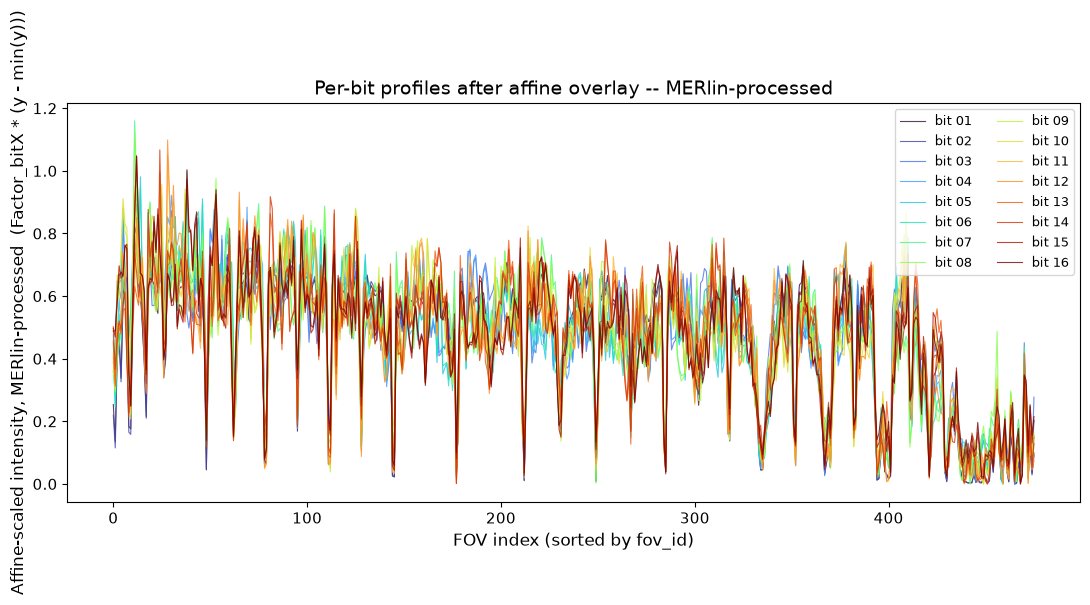

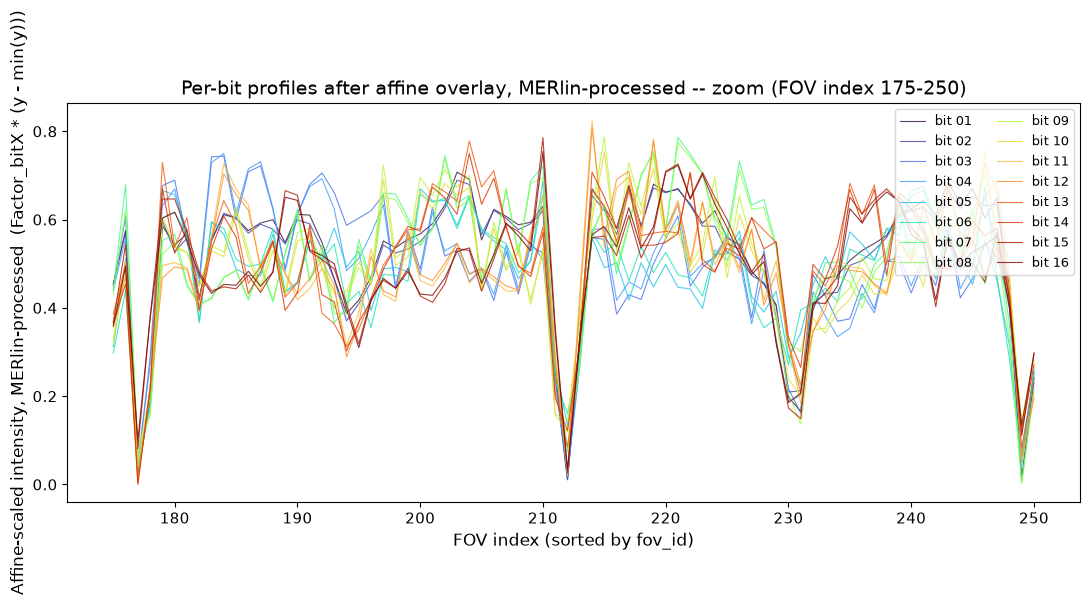

Factor_bitX (MERlin-processed):
1     0.017190
2     0.009991
3     0.019810
4     0.013994
5     0.020869
6     0.013909
7     0.023320
8     0.015913
9     0.023270
10    0.014534
11    0.019101
12    0.012648
13    0.017298
14    0.014026
15    0.020582
16    0.013395


In [12]:
min_per_bit_processed = wide_processed.min(axis=0)
range_per_bit_processed = wide_processed.max(axis=0) - min_per_bit_processed
centered_processed = wide_processed.subtract(min_per_bit_processed, axis=1)
normalized_01_processed = centered_processed.divide(range_per_bit_processed, axis=1)
consensus_processed = normalized_01_processed.mean(axis=1).values

factor_per_bit_processed = {}
for b in bits:
    y = centered_processed[b].values
    factor_per_bit_processed[b] = float(np.dot(y, consensus_processed) / np.dot(y, y))
factor_series_processed = pd.Series(factor_per_bit_processed).sort_index()

scaled_processed = centered_processed.multiply(factor_series_processed, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, scaled_processed[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity, MERlin-processed  (Factor_bitX * (y - min(y)))",
              fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Per-bit profiles after affine overlay -- MERlin-processed", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay_merlin_processed.png", dpi=150)
plt.show()

# Zoom: FOV index 175-250, restricted to that range (not just an xlim on the
# full-range plot above) so the y-axis autoscales to the zoomed-in data too.
zoom_mask = (fov_index >= 175) & (fov_index <= 250)
fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index[zoom_mask], scaled_processed[b].values[zoom_mask], "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity, MERlin-processed  (Factor_bitX * (y - min(y)))",
              fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Per-bit profiles after affine overlay, MERlin-processed -- zoom (FOV index 175-250)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay_merlin_processed_zoom_175_250.png", dpi=150)
plt.show()

print("Factor_bitX (MERlin-processed):")
print(factor_series_processed.to_string())

## 13 — Raw vs. MERlin-processed vs. Optimize09: which one actually tracks MERlin's own scale factor?

Repeats section 8's comparison for both starting points side by side --
`1/Factor_bitX` from the raw calculation (section 7) and from the
MERlin-processed one (section 12), each against MERlin's real converged
`Optimize10` scale factor -- plus a third panel comparing `Optimize10`
directly to the previous iteration, `Optimize09` (both already in MERlin's
own scale-factor units, so no `1/Factor_bitX` inversion needed here): how
much did the chained `OptimizeIteration` sequence still move in its last
step?

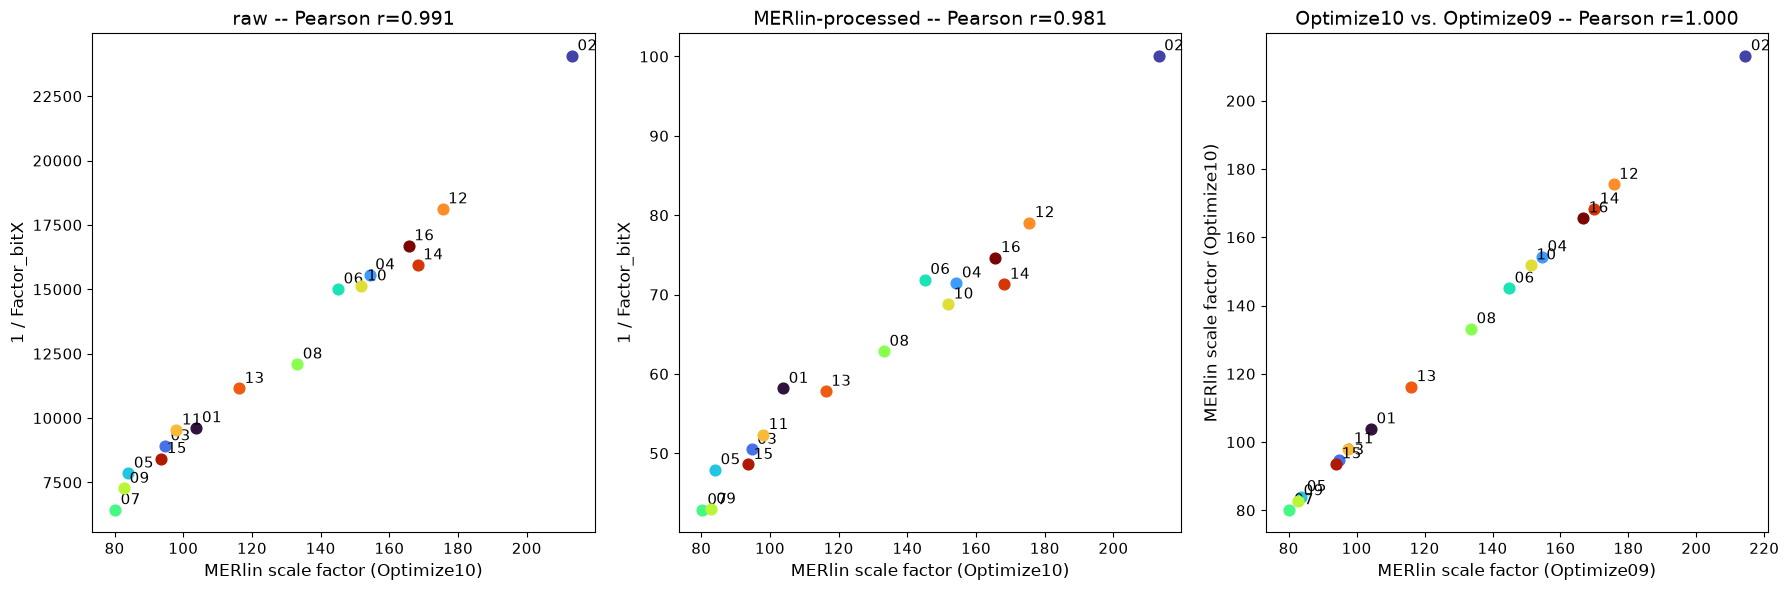

    Factor_bitX_raw  1/Factor_bitX_raw  merlin_scale_factor  Factor_bitX_merlin_processed  1/Factor_bitX_merlin_processed  merlin_scale_factor_optimize09
1            0.0001          9622.9006             103.8476                        0.0172                         58.1745                        104.2261
2            0.0000         24068.6264             213.1545                        0.0100                        100.0855                        214.4216
3            0.0001          8917.6618              94.6972                        0.0198                         50.4795                         94.7893
4            0.0001         15561.3438             154.2823                        0.0140                         71.4589                        154.5709
5            0.0001          7857.8742              84.0162                        0.0209                         47.9183                         83.7096
6            0.0001         15011.8633             145.0782                 

In [13]:
comparison_both = comparison.rename(columns={"Factor_bitX": "Factor_bitX_raw", "1/Factor_bitX": "1/Factor_bitX_raw"})
comparison_both["Factor_bitX_merlin_processed"] = factor_series_processed
comparison_both["1/Factor_bitX_merlin_processed"] = 1.0 / factor_series_processed

r_raw = r   # already computed in section 8
r_processed = np.corrcoef(comparison_both["1/Factor_bitX_merlin_processed"],
                          comparison_both["merlin_scale_factor"])[0, 1]

# Optimize09 -- the iteration immediately before the Optimize10 MERlin actually
# uses (section 8) -- in the same OptimizeXX/scale_factors.npy layout.
merlin_scale_factors_09 = np.load(SAMPLE_DIR / "merlin" / "output" / "Optimize09" / "scale_factors.npy")
comparison_both["merlin_scale_factor_optimize09"] = pd.Series(
    {i + 1: float(v) for i, v in enumerate(merlin_scale_factors_09)}).sort_index()
r_optimize09 = np.corrcoef(comparison_both["merlin_scale_factor_optimize09"],
                           comparison_both["merlin_scale_factor"])[0, 1]

# Separate (not shared) y-axes: raw and MERlin-processed 1/Factor_bitX sit on
# very different scales (~1e4 vs. ~1e2), so a shared axis flattens one panel.
fig, (ax_raw, ax_processed, ax_optimize) = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title, r_val in [
    (ax_raw, "1/Factor_bitX_raw", "raw", r_raw),
    (ax_processed, "1/Factor_bitX_merlin_processed", "MERlin-processed", r_processed),
]:
    for b in bits:
        ax.scatter(comparison_both.loc[b, "merlin_scale_factor"], comparison_both.loc[b, col],
                   color=color_of[b], s=60, zorder=3)
        ax.annotate(f"{b:02d}", (comparison_both.loc[b, "merlin_scale_factor"], comparison_both.loc[b, col]),
                    fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("1 / Factor_bitX", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{title} -- Pearson r={r_val:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

for b in bits:
    ax_optimize.scatter(comparison_both.loc[b, "merlin_scale_factor_optimize09"],
                        comparison_both.loc[b, "merlin_scale_factor"],
                        color=color_of[b], s=60, zorder=3)
    ax_optimize.annotate(f"{b:02d}", (comparison_both.loc[b, "merlin_scale_factor_optimize09"],
                                      comparison_both.loc[b, "merlin_scale_factor"]),
                         fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
ax_optimize.set_xlabel("MERlin scale factor (Optimize09)", fontsize=PLOT_LABEL_FONTSIZE)
ax_optimize.set_ylabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
ax_optimize.set_title(f"Optimize10 vs. Optimize09 -- Pearson r={r_optimize09:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
ax_optimize.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_comparison_raw_vs_merlin_processed.png", dpi=150)
plt.show()

print(comparison_both.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nPearson r, raw intensity:               {r_raw:.4f}")
print(f"Pearson r, MERlin-processed intensity:  {r_processed:.4f}")
print(f"Pearson r, Optimize10 vs. Optimize09:    {r_optimize09:.4f}")

## 14 — Convergence of MERlin's own scale factors toward Optimize10

Section 13's third panel checked only the last step (`Optimize09` ->
`Optimize10`). This extends that to the whole chained sequence: for each
earlier iteration `Optimize01` .. `Optimize09`, the Pearson correlation of
its 16 per-bit scale factors against `Optimize10`'s (already loaded in
section 8 as `merlin_per_bit`) -- one point per iteration, plotted against
iteration number, to see how quickly the sequence converges.

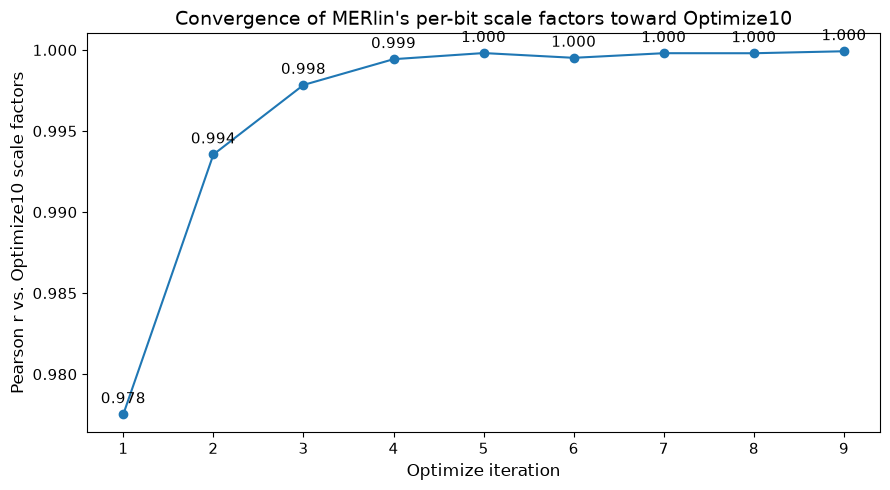

1   0.9775
2   0.9936
3   0.9978
4   0.9994
5   0.9998
6   0.9995
7   0.9998
8   0.9998
9   0.9999


In [14]:
optimize_rounds = list(range(1, 10))   # Optimize01 .. Optimize09, each vs. Optimize10 (merlin_per_bit, section 8)

r_by_round = {}
for round_num in optimize_rounds:
    round_factors = np.load(SAMPLE_DIR / "merlin" / "output" / f"Optimize{round_num:02d}" / "scale_factors.npy")
    round_per_bit = pd.Series({i + 1: float(v) for i, v in enumerate(round_factors)}).sort_index()
    r_by_round[round_num] = np.corrcoef(round_per_bit, merlin_per_bit)[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(optimize_rounds, [r_by_round[rd] for rd in optimize_rounds], "-o", color="tab:blue", zorder=3)
for rd in optimize_rounds:
    ax.annotate(f"{r_by_round[rd]:.3f}", (rd, r_by_round[rd]), fontsize=PLOT_TICK_FONTSIZE,
                xytext=(0, 8), textcoords="offset points", ha="center")
ax.set_xlabel("Optimize iteration", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Pearson r vs. Optimize10 scale factors", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Convergence of MERlin's per-bit scale factors toward Optimize10", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xticks(optimize_rounds)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_convergence.png", dpi=150)
plt.show()

print(pd.Series(r_by_round, name="pearson_r").to_string(float_format=lambda v: f"{v:.4f}"))

## 15 — Affine overlay restricted to top-50%-intensity FOVs (raw)

Repeats section 7's affine-overlay fit (`Factor_bitX = <(y - min(y)),
consensus> / <(y - min(y)), (y - min(y))>`), but only on the subset of FOVs
where **every one of the 16 bits'** raw intensity is in the top 50% of that
bit's own per-FOV distribution (`>=` its median across all 476 FOVs) --
i.e. FOVs that are bright across all bits simultaneously, not just bright
on average.

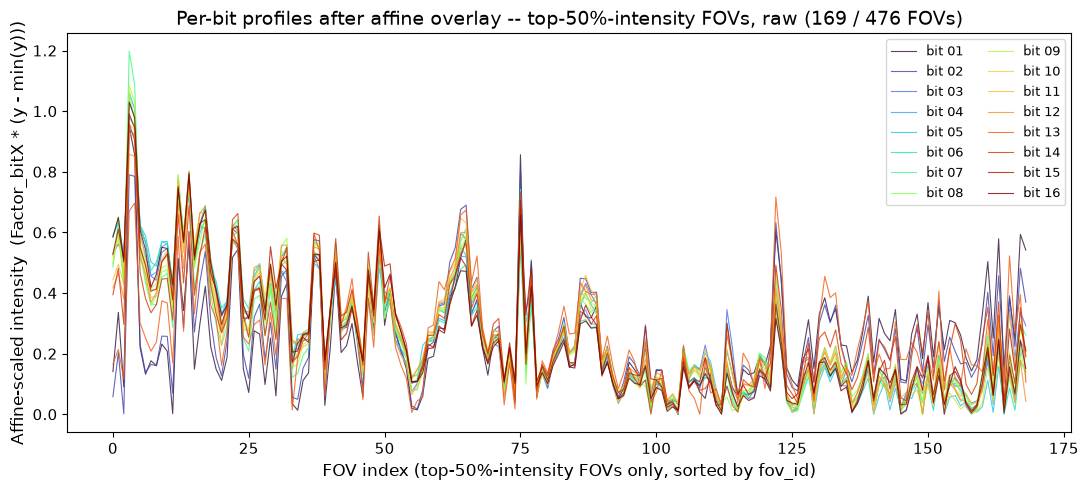

169 / 476 FOVs kept (top 50% of every bit's raw intensity distribution).
Factor_bitX (top-50%-intensity FOVs, raw):
1     0.000229
2     0.000093
3     0.000235
4     0.000104
5     0.000199
6     0.000100
7     0.000297
8     0.000140
9     0.000246
10    0.000094
11    0.000214
12    0.000093
13    0.000223
14    0.000120
15    0.000199
16    0.000095


In [15]:
median_per_bit = wide.median(axis=0)
top50_mask = (wide >= median_per_bit).all(axis=1)   # FOV kept only if ALL 16 bits are >= their own median
wide_top50 = wide.loc[top50_mask]
fov_index_top50 = np.arange(len(wide_top50))

min_per_bit_top50 = wide_top50.min(axis=0)
range_per_bit_top50 = wide_top50.max(axis=0) - min_per_bit_top50
centered_top50 = wide_top50.subtract(min_per_bit_top50, axis=1)
normalized_01_top50 = centered_top50.divide(range_per_bit_top50, axis=1)
consensus_top50 = normalized_01_top50.mean(axis=1).values

factor_per_bit_top50 = {}
for b in bits:
    y = centered_top50[b].values
    factor_per_bit_top50[b] = float(np.dot(y, consensus_top50) / np.dot(y, y))
factor_series_top50 = pd.Series(factor_per_bit_top50).sort_index()

scaled_top50 = centered_top50.multiply(factor_series_top50, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index_top50, scaled_top50[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (top-50%-intensity FOVs only, sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity  (Factor_bitX * (y - min(y)))", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit profiles after affine overlay -- top-50%-intensity FOVs, raw "
             f"({len(wide_top50)} / {len(wide)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay_top50.png", dpi=150)
plt.show()

print(f"{len(wide_top50)} / {len(wide)} FOVs kept (top 50% of every bit's raw intensity distribution).")
print("Factor_bitX (top-50%-intensity FOVs, raw):")
print(factor_series_top50.to_string())

## 16 — Per-bit scaling comparison, top-50%-intensity FOVs (raw)

Repeats section 8's comparison (`1/Factor_bitX` vs. MERlin's real converged
`Optimize10` scale factor), computed from section 15's top-50%-intensity-FOV
subset instead of all FOVs.

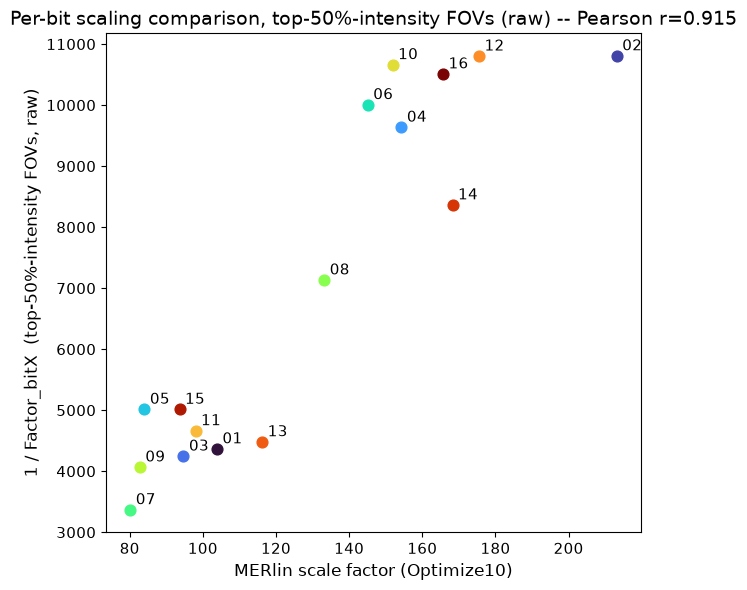

    Factor_bitX  1/Factor_bitX  merlin_scale_factor
1        0.0002      4366.6121             103.8476
2        0.0001     10807.9073             213.1545
3        0.0002      4246.4288              94.6972
4        0.0001      9637.7664             154.2823
5        0.0002      5014.8170              84.0162
6        0.0001     10006.8257             145.0782
7        0.0003      3368.7417              80.1644
8        0.0001      7134.1112             133.1816
9        0.0002      4068.3295              82.7678
10       0.0001     10662.6320             151.8815
11       0.0002      4663.6669              97.9998
12       0.0001     10803.7766             175.4937
13       0.0002      4482.4901             116.2236
14       0.0001      8364.7576             168.2566
15       0.0002      5014.5328              93.6160
16       0.0001     10510.9978             165.6545

Pearson r (1/Factor_bitX vs. MERlin scale factor, top-50%-intensity FOVs, raw): 0.9151


In [16]:
inv_factor_series_top50 = 1.0 / factor_series_top50

comparison_top50 = pd.DataFrame({
    "Factor_bitX":            factor_series_top50,
    "1/Factor_bitX":          inv_factor_series_top50,
    "merlin_scale_factor":    merlin_per_bit,
})
r_top50 = np.corrcoef(comparison_top50["1/Factor_bitX"], comparison_top50["merlin_scale_factor"])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for b in bits:
    ax.scatter(comparison_top50.loc[b, "merlin_scale_factor"], comparison_top50.loc[b, "1/Factor_bitX"],
               color=color_of[b], s=60, zorder=3)
    ax.annotate(f"{b:02d}", (comparison_top50.loc[b, "merlin_scale_factor"], comparison_top50.loc[b, "1/Factor_bitX"]),
                fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("1 / Factor_bitX  (top-50%-intensity FOVs, raw)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit scaling comparison, top-50%-intensity FOVs (raw) -- Pearson r={r_top50:.3f}",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_comparison_top50.png", dpi=150)
plt.show()

print(comparison_top50.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nPearson r (1/Factor_bitX vs. MERlin scale factor, top-50%-intensity FOVs, raw): {r_top50:.4f}")

## 17 — Affine overlay restricted to top-50%-intensity FOVs (MERlin-processed)

Same restriction as section 15, applied to the MERlin-processed (deconvolved)
images from sections 9-12: FOVs kept only if **every one of the 16 bits'**
MERlin-processed intensity is in the top 50% of that bit's own per-FOV
distribution.

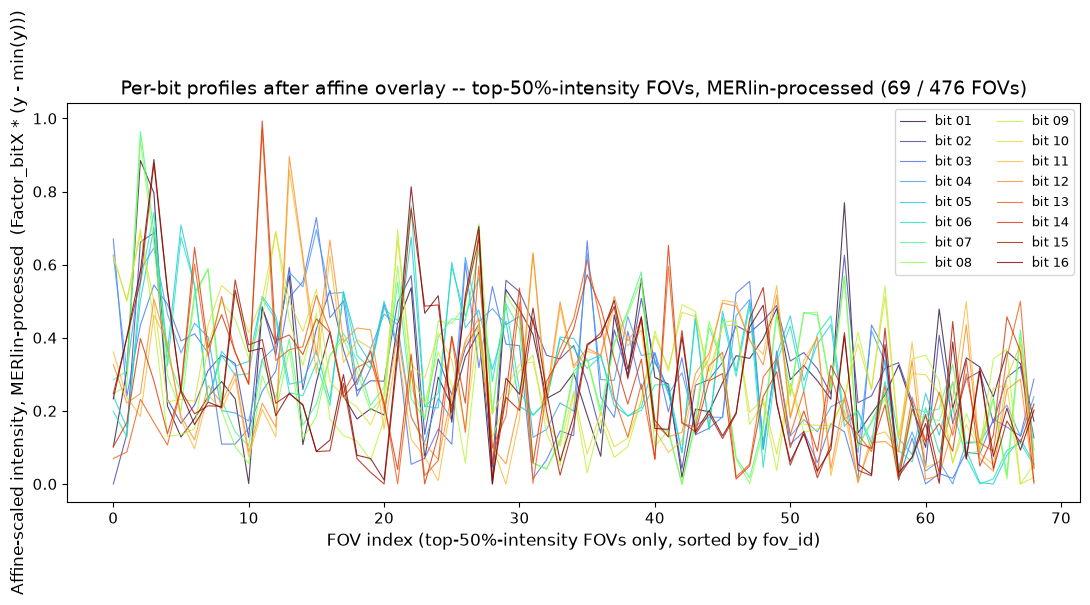

69 / 476 FOVs kept (top 50% of every bit's MERlin-processed intensity distribution).
Factor_bitX (top-50%-intensity FOVs, MERlin-processed):
1     0.060748
2     0.034506
3     0.040500
4     0.023587
5     0.030473
6     0.022378
7     0.033896
8     0.024519
9     0.038080
10    0.021361
11    0.030215
12    0.019996
13    0.035034
14    0.025528
15    0.033966
16    0.022812


In [17]:
median_per_bit_processed = wide_processed.median(axis=0)
top50_mask_processed = (wide_processed >= median_per_bit_processed).all(axis=1)
wide_processed_top50 = wide_processed.loc[top50_mask_processed]
fov_index_processed_top50 = np.arange(len(wide_processed_top50))

min_per_bit_processed_top50 = wide_processed_top50.min(axis=0)
range_per_bit_processed_top50 = wide_processed_top50.max(axis=0) - min_per_bit_processed_top50
centered_processed_top50 = wide_processed_top50.subtract(min_per_bit_processed_top50, axis=1)
normalized_01_processed_top50 = centered_processed_top50.divide(range_per_bit_processed_top50, axis=1)
consensus_processed_top50 = normalized_01_processed_top50.mean(axis=1).values

factor_per_bit_processed_top50 = {}
for b in bits:
    y = centered_processed_top50[b].values
    factor_per_bit_processed_top50[b] = float(np.dot(y, consensus_processed_top50) / np.dot(y, y))
factor_series_processed_top50 = pd.Series(factor_per_bit_processed_top50).sort_index()

scaled_processed_top50 = centered_processed_top50.multiply(factor_series_processed_top50, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index_processed_top50, scaled_processed_top50[b].values, "-", lw=0.8, alpha=0.8,
            color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (top-50%-intensity FOVs only, sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity, MERlin-processed  (Factor_bitX * (y - min(y)))",
              fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit profiles after affine overlay -- top-50%-intensity FOVs, MERlin-processed "
             f"({len(wide_processed_top50)} / {len(wide_processed)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay_merlin_processed_top50.png", dpi=150)
plt.show()

print(f"{len(wide_processed_top50)} / {len(wide_processed)} FOVs kept "
      f"(top 50% of every bit's MERlin-processed intensity distribution).")
print("Factor_bitX (top-50%-intensity FOVs, MERlin-processed):")
print(factor_series_processed_top50.to_string())

## 18 — Per-bit scaling comparison, top-50%-intensity FOVs (MERlin-processed)

Repeats section 13's MERlin-processed comparison (`1/Factor_bitX` vs.
MERlin's real converged `Optimize10` scale factor), computed from section
17's top-50%-intensity-FOV subset instead of all FOVs.

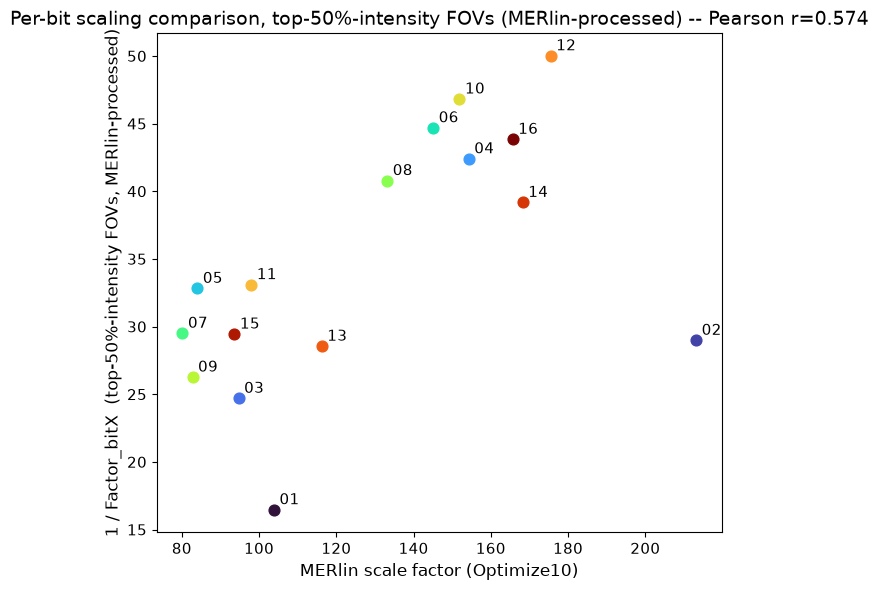

    Factor_bitX  1/Factor_bitX  merlin_scale_factor
1        0.0607        16.4614             103.8476
2        0.0345        28.9809             213.1545
3        0.0405        24.6914              94.6972
4        0.0236        42.3967             154.2823
5        0.0305        32.8164              84.0162
6        0.0224        44.6864             145.0782
7        0.0339        29.5023              80.1644
8        0.0245        40.7841             133.1816
9        0.0381        26.2608              82.7678
10       0.0214        46.8150             151.8815
11       0.0302        33.0963              97.9998
12       0.0200        50.0102             175.4937
13       0.0350        28.5438             116.2236
14       0.0255        39.1729             168.2566
15       0.0340        29.4410              93.6160
16       0.0228        43.8364             165.6545

Pearson r (1/Factor_bitX vs. MERlin scale factor, top-50%-intensity FOVs, MERlin-processed): 0.5738


In [18]:
inv_factor_series_processed_top50 = 1.0 / factor_series_processed_top50

comparison_processed_top50 = pd.DataFrame({
    "Factor_bitX":            factor_series_processed_top50,
    "1/Factor_bitX":          inv_factor_series_processed_top50,
    "merlin_scale_factor":    merlin_per_bit,
})
r_processed_top50 = np.corrcoef(comparison_processed_top50["1/Factor_bitX"],
                                comparison_processed_top50["merlin_scale_factor"])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for b in bits:
    ax.scatter(comparison_processed_top50.loc[b, "merlin_scale_factor"],
               comparison_processed_top50.loc[b, "1/Factor_bitX"],
               color=color_of[b], s=60, zorder=3)
    ax.annotate(f"{b:02d}", (comparison_processed_top50.loc[b, "merlin_scale_factor"],
                              comparison_processed_top50.loc[b, "1/Factor_bitX"]),
                fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("1 / Factor_bitX  (top-50%-intensity FOVs, MERlin-processed)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit scaling comparison, top-50%-intensity FOVs (MERlin-processed) -- "
             f"Pearson r={r_processed_top50:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_comparison_merlin_processed_top50.png", dpi=150)
plt.show()

print(comparison_processed_top50.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nPearson r (1/Factor_bitX vs. MERlin scale factor, top-50%-intensity FOVs, MERlin-processed): "
      f"{r_processed_top50:.4f}")